# Spatial cell-cell communication with CellChat - PENDING
## Will be only for plotting result objects from 4_cosmx...R


Adapted from the tutorial for SpatialCellChat. 

[SpatialCellChat_analysis_of_spatial_transcriptomics_data]('https://htmlpreview.github.io/?https://github.com/jinworks/SpatialCellChat/blob/master/tutorial/SpatialCellChat_analysis_of_spatial_transcriptomics_data.html')

In [1]:
## sbatch --mem=180G -p tier2q  ./launch_jupyter_conda.sh /gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/conda_envs/seurat_spatial

## LIBRARIES
library(Seurat)
library(SpatialCellChat)
library(Matrix)
library(patchwork)
library(dplyr)
options(stringsAsFactors = F)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: igraph


Attaching package: ‘igraph’


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following object is masked from ‘package:Seurat’:

    components


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




## Run SpatialCellChat

In [2]:
## Create seurat object with Subset data. 
in_dir = './CosMx/results/BreastCancer/Subset_MM'
out_dir = './CosMx/results/BreastCancer/SpatialCellChat'
dir.create(out_dir, showWarnings = F)

# 1. Load counts and create base object
## Read mtx file directly 
counts = readMM(file.path(in_dir, "matrix.mtx"))
barcodes = read.table(file.path(in_dir, "barcodes.tsv"), header = FALSE)$V1
features = read.table(file.path(in_dir, "features.tsv"), header = FALSE, sep = "\t")

rownames(counts) = features$V2  # gene names (col 2), or V1 for IDs
colnames(counts) = barcodes


seurat_obj = CreateSeuratObject(counts = counts)

Warning message:
“Data is of class dgTMatrix. Coercing to dgCMatrix.”


In [3]:
# 2. Add cell metadata (with annotations)
metadata = read.csv(file.path(in_dir, "metadata_annotation.csv"), row.names = 1)

# Make sure cell names match
all(rownames(metadata) == colnames(seurat_obj))  # should be TRUE

seurat_obj = AddMetaData(seurat_obj, metadata)

[1] TRUE

In [ ]:
head(seurat_obj)

,orig.ident,nCount_RNA,nFeature_RNA,fov,Area,AspectRatio,CenterX_local_px,CenterY_local_px,Width,Height,⋯,leiden_0.2,leiden_0.4,leiden_0.6,ct_major_Cells_Adult_Breast,ct_major_Immune_All_Low,ct_major_Immune_All_High,ct_conf_Cells_Adult_Breast,ct_conf_Immune_All_Low,ct_conf_Immune_All_High,final_annotation
,<fct>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
43430,SeuratProject,2183,1350,70,7370,0.61,63,38,126,77,⋯,0,0,0,LummHR-SCGB,Epithelial cells,Epithelial cells,0.99605282,1.0000000,1.0000000,LummHR-SCGB
43431,SeuratProject,3563,2250,70,7594,0.97,489,54,105,108,⋯,0,2,3,LummHR-SCGB,Epithelial cells,Epithelial cells,0.98212689,0.9999886,0.9999993,LummHR-SCGB
43432,SeuratProject,2879,1830,70,7630,0.97,578,58,112,116,⋯,0,2,3,LummHR-SCGB,Epithelial cells,Epithelial cells,0.51802058,1.0000000,1.0000000,LummHR-SCGB
43433,SeuratProject,1238,814,70,3466,0.63,612,27,88,55,⋯,0,2,0,LummHR-SCGB,Epithelial cells,Epithelial cells,0.70229108,0.9955696,0.9996173,LummHR-SCGB
43434,SeuratProject,1220,684,70,9646,0.86,876,50,116,100,⋯,1,4,2,Macro-lipo,Epithelial cells,Macrophages,0.96898910,0.9955328,0.9990084,Macrophages
43435,SeuratProject,1290,898,70,5142,0.88,1062,42,95,84,⋯,1,6,5,pericytes,Fibroblasts,Macrophages,0.98126678,0.8814559,0.2448457,Macrophages
43436,SeuratProject,259,192,70,1440,0.29,1195,11,79,23,⋯,2,1,1,pericytes,Epithelial cells,Epithelial cells,0.47949220,0.9890577,0.9603021,Epithelial cells
43437,SeuratProject,1577,858,70,11639,0.59,1922,49,165,98,⋯,0,2,10,LummHR-SCGB,Epithelial cells,Epithelial cells,0.09164974,0.9998144,0.9997353,LummHR-SCGB
43438,SeuratProject,351,263,70,1074,0.34,2035,10,62,21,⋯,2,1,1,pericytes,Epithelial cells,Epithelial cells,0.22638595,0.7310239,0.8460797,Epithelial cells


In [85]:
## Quick filter to test data. 
summary(seurat_obj$CenterX_global_px)
summary(seurat_obj$CenterY_global_px)

seurat_obj = subset(seurat_obj, CenterX_global_px > 35000  & CenterY_global_px < 98000)


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  21549   26261   31878   31812   36990   42800 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  93787   97767  102127  102220  106632  110790 

In [86]:
seurat_obj

An object of class Seurat 
20334 features across 2666 samples within 1 assay 
Active assay: RNA (20334 features, 0 variable features)
 2 layers present: counts, data

Once we have produced the Seurat object, let's make sure the normalized data is also added, or load it if you have a prefered normalized counts matrix. 

In [87]:
## 3. Normalize data
seurat_obj = NormalizeData(seurat_obj)

Normalizing layer: counts



## Spatial data formatting

For CosMx, we have 5 pieces of spatial information: 
    * FOV
    * CenterX_local_px and CenterY_local_px: Within FOV pixel position.
    * CenterX_global_px and CenterY_global_px: Global, pixel position.
    
Since we want to convert it to nm resolution, we require a conversion factor. 
For CosMx, we know that a pixel edge length is 120 nm, to convert to microns. 

`conversion.factor = 0.12028`

Since CosMx is done at the cell-level and thus, do not have uniforma cell size, we can use as a tolerance factor half the minimum centroid-to-centroid distance between cells. 

From the notes in SpatialCellChat:

[CellChat, CosMx](https://htmlpreview.github.io/?https://github.com/jinworks/CellChat/blob/master/tutorial/FAQ_on_applying_CellChat_to_spatial_transcriptomics_data.html#cosmx)

*_"CellChat does not need an accurate tolerance factor, which is used for determining whether considering the cell-pair as spatially proximal if their distance is greater than interaction.range but smaller than “interaction.range + tol”._*

In [95]:
conversion.factor = 0.12028 ## Conversion factor for CosMx. 

## Load spatial coordinates - CenterX_global_px and CenterY_global_px columns in metadata.
spatial_coords = dplyr::select(seurat_obj@meta.data, CenterX_global_px, CenterY_global_px) %>%
    rename(x = CenterX_global_px, y = CenterY_global_px) %>% as.matrix()


In [97]:
d = dist(spatial_coords, method = 'euclidean') ## Instead of computeCellDistance, function is not working well. 
## Calculate approximate spot size based on the minimum distance between spots.
spot.size = min(d)*conversion.factor # converting the distance in Pixels to Micrometers
spatial.factors = data.frame(ratio = conversion.factor, tol = spot.size/2)

## Create Spatial Cell Chat obj

In [98]:
## Create Spatial CellChat obj. 
chat = createSpatialCellChat(
    object = seurat_obj, 
    group.by = "final_annotation", 
    assay = "RNA", 
    datatype = "spatial",
    coordinates = spatial_coords, 
    spatial.factors = spatial.factors
    )


ℹ Create a SpatialCellChat object from a Seurat object.
The `meta.data` slot in the Seurat object is used as cell meta information 
Create a SpatialCellChat object from spatial imaging data... 
Set cell identities for the new SpatialCellChat object 
The cell groups used for SpatialCellChat analysis are  Endothelial cells Epithelial cells LummHR-SCGB Lumsec-prol Macrophages Plasma cells 


You can choose between the human and mouse database. Here we use the human database as an example. You can select a subset of the interactions, depending on your interest, i.e. type of signaling (`annotation` column). 

In [29]:
CellChatDB = CellChatDB.human # use CellChatDB.mouse if running on mouse data

# Show the structure of the database
dplyr::glimpse(CellChatDB$interaction)

Rows: 3,234
Columns: 28
$ interaction_name         <chr> "TGFB1_TGFBR1_TGFBR2", "TGFB2_TGFBR1_TGFBR2",…
$ pathway_name             <chr> "TGFb", "TGFb", "TGFb", "TGFb", "TGFb", "TGFb…
$ ligand                   <chr> "TGFB1", "TGFB2", "TGFB3", "TGFB1", "TGFB1", …
$ receptor                 <chr> "TGFbR1_R2", "TGFbR1_R2", "TGFbR1_R2", "ACVR1…
$ agonist                  <chr> "TGFb agonist", "TGFb agonist", "TGFb agonist…
$ antagonist               <chr> "TGFb antagonist", "TGFb antagonist", "TGFb a…
$ co_A_receptor            <chr> "", "", "", "", "", "", "", "", "", "", "", "…
$ co_I_receptor            <chr> "TGFb inhibition receptor", "TGFb inhibition …
$ evidence                 <chr> "KEGG: hsa04350", "KEGG: hsa04350", "KEGG: hs…
$ annotation               <chr> "Secreted Signaling", "Secreted Signaling", "…
$ interaction_name_2       <chr> "TGFB1 - (TGFBR1+TGFBR2)", "TGFB2 - (TGFBR1+T…
$ is_neurotransmitter      <lgl> FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, FAL…
$ ligand.symbol 

In [30]:
table(CellChatDB$interaction$annotation)


    Cell-Cell Contact          ECM-Receptor Non-protein Signaling 
                  536                   424                   994 
   Secreted Signaling 
                 1280 

In [99]:
## Set the database to use for this analysis.  For this case, only cell-cell contact. 
CellChatDB_subset = subsetDB(CellChatDB, search = list(c("Cell-Cell Contact")), key = c("annotation"))
chat@DB = CellChatDB_subset

## Preprocessing data

In this step, we identify spatially-variable genes, and then identify spatially-variable interactions, defined as such if ligand and/or receptor was spatially-variable. 

In [100]:
# subset the expression data of signaling genes for saving computation cost
chat = subsetData(chat) # This step is necessary even if using the whole database
chat = preProcessing(chat) # the function now requires only 1 argument, which is the object itself

ℹ Pre-processing from a SpatialCellChat object.
✔ Pre-processing is done.


In [101]:
chat

An object of class SpatialCellChat created from a single dataset 
 20334 genes.
 2666 cells. 
SpatialCellChat analysis of spatial data! The input spatial locations are 
       x_cent y_cent
101032  35036  97968
101033  35150  97991
101037  36065  97979
101038  36514  97983
101042  37633  97984
101044  38180  97995

In [102]:
## Identify over-expressed genes and interactions
chat = identifyOverExpressedGenes(
  chat,
  ## Methods: 'wilcox', 'meringue' & "moransi"
  selection.method = "meringue", # method for selecting (spatially) variable features
  do.grid = FALSE # if true, do "grid" operation to speed up computation
)

>>>  Choose spatially variable features using 'MERINGUE' method... 
>>>  The number of highly variable features is 305 


In [68]:
chat = CellChat::identifyOverExpressedGenes(
  chat,
  do.DE = F,
  min.cells = 10
)

ERROR: Error in loadNamespace(x): there is no package called ‘CellChat’


In [110]:
?identifyOverExpressedInteractions

identifyOverExpressedInteractionspackage:SpatialCellChatR Documentation

_I_d_e_n_t_i_f_y _o_v_e_r-_e_x_p_r_e_s_s_e_d _l_i_g_a_n_d-_r_e_c_e_p_t_o_r _i_n_t_e_r_a_c_t_i_o_n_s (_p_a_i_r_s) _w_i_t_h_i_n _t_h_e
_u_s_e_d _C_e_l_l_C_h_a_t_D_B

_D_e_s_c_r_i_p_t_i_o_n:

     Identify over-expressed ligand-receptor interactions (pairs)
     within the used CellChatDB

_U_s_a_g_e:

     identifyOverExpressedInteractions(
       object,
       features.name = "features",
       variable.both = TRUE,
       features = NULL,
       return.object = TRUE
     )
     
_A_r_g_u_m_e_n_t_s:

  object: CellChat object

features.name: a char name used for assess the results in
          `object@var.features[[features.name]]`

variable.both: variable.both = TRUE will require that both ligand and
          receptor from one pair are over-expressed;

          variable.both = FALSE will only require that either 

In [115]:
progressr::without_progress({
  chat = identifyOverExpressedInteractions(chat, variable.both = F)
})
#chat = identifyOverExpressedInteractions(chat, variable.both = F) # only require that either ligand or receptor from one pair is over-expressed

ℹ Future strategy in use: `sequential`


ERROR: Error in globalCallingHandlers(condition = global_progression_handler): should not be called with handlers on the stack


## Communication probabilities and network at the individual cell level

In [9]:
chat = computeCommunProb(
  chat,
  distance.use = TRUE, scale.distance = 1,
  #contact.dependent = TRUE,
  interaction.range = 250, contact.range = 10
)

>>>  Analyzing spatial transcriptomic data and preferring to infer interactions between individual cells...
>>>  Apply a predefined spatial distance threshold based on the interaction length(=250um)...
>>> Contact range is set as 10um, to restrict the contact-dependent signaling.
>>> Run CellChat on spatial transcriptomic data using distances as constraints <<< [2026-04-01 22:52:27.63937]
>>>  All the input L-R pairs are `Cell-Cell Contact` signaling. Run CellChat in a contact-dependent manner. 


ERROR: Error in globalCallingHandlers(condition = global_progression_handler): should not be called with handlers on the stack


In [ ]:
## Filter out to keep only significant interactions. 
chat = filterProbability(chat)

## Filter based on number of cells supporting the interaction.
chat = filterCommunication(
  chat, min.cells = NULL,
  min.links = 10,
  min.cells.sr = 10
)

saveRDS(chat, file = file.path(out_dir, "chat_computeCommunProb.rds"))    

## Network - Post-script

In [2]:
chat = readRDS('./CosMx/results/SpatialCellChat/SpatialCellChat_communication.rds')

In [3]:
chat

An object of class SpatialCellChat created from a single dataset 
 20334 genes.
 2666 cells. 
SpatialCellChat analysis of spatial data! The input spatial locations are 
       x_cent y_cent
101032  35036  97968
101033  35150  97991
101037  36065  97979
101038  36514  97983
101042  37633  97984
101044  38180  97995

In [ ]:
class(chat@net$prob) 
dim(chat@net$prob)

[1] "sparse3Darray"

[1] 2666 2666  467

In [5]:
dim(chat@data.signaling)

[1]  339 2666

[1] 2666 2666  467

NULL

[1] "prob.cell" "tmp"

In [11]:
chat = aggregateNet(chat)

ERROR: Error in `==.sparse3Darray`(prob, 0): Both arguments must be of class 'sparse3Darray'


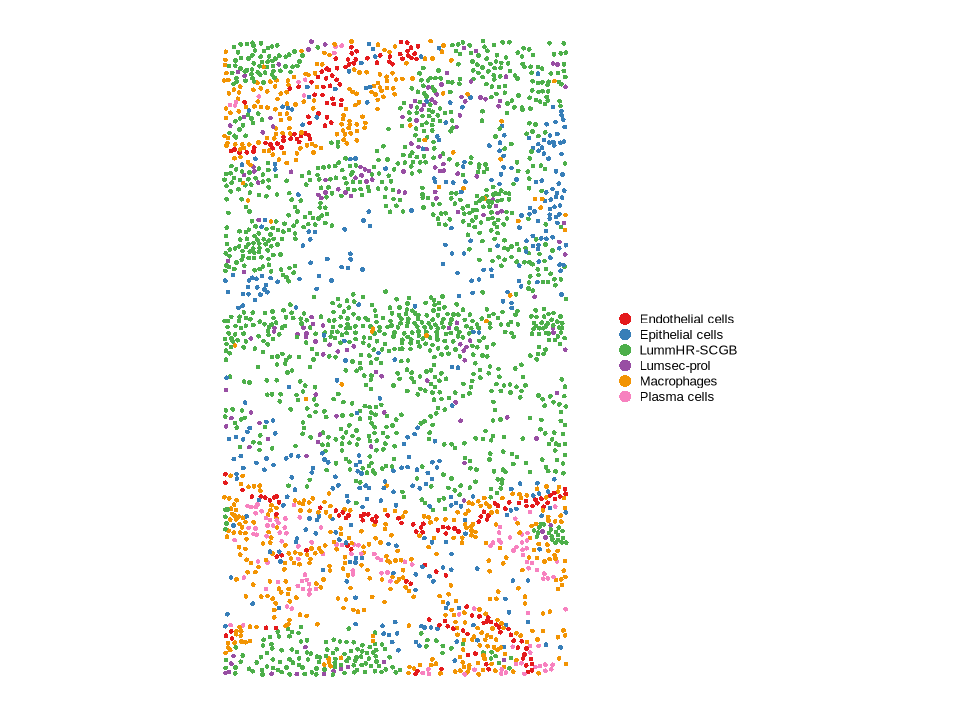

In [6]:
options(repr.plot.width = 8, repr.plot.height = 6)
spatialDimPlot(chat, group.by='final_annotation', point.size = 1)

In [5]:
str(chat@netP)

List of 5
 $ pathways     : chr [1:81] "ADGRL" "EPHA" "MHC-I" "NRXN" ...
 $ prob         : num [1:2666, 1:2666, 1:81] 0.1 0 0 0 0 ...
  ..- attr(*, "dimnames")=List of 3
  .. ..$ : chr [1:2666] "101032" "101033" "101037" "101038" ...
  .. ..$ : chr [1:2666] "101032" "101033" "101037" "101038" ...
  .. ..$ : chr [1:81] "ADGRL" "EPHA" "MHC-I" "NRXN" ...
 $ pathways.cell: chr [1:81] "ADGRL" "EPHA" "MHC-I" "NRXN" ...
 $ prob.cell    :List of 6
  ..$ i       : int [1:91158] 1 2 28 3 4 5 7 13 8 38 ...
  ..$ j       : int [1:91158] 1 2 2 3 4 5 7 7 8 8 ...
  ..$ k       : int [1:91158] 1 1 1 1 1 1 1 1 1 1 ...
  ..$ x       : num [1:91158] 0.10006 0.02588 0.00585 0.37177 0.21977 ...
  ..$ dim     : int [1:3] 2666 2666 81
  ..$ dimnames:List of 3
  .. ..$ : chr [1:2666] "101032" "101033" "101037" "101038" ...
  .. ..$ : chr [1:2666] "101032" "101033" "101037" "101038" ...
  .. ..$ : chr [1:81] "ADGRL" "EPHA" "MHC-I" "NRXN" ...
  ..- attr(*, "class")= chr "sparse3Darray"
 $ tmp          :List of 

In [9]:
chat@netP$pathways

[1] "ADGRL"     "EPHA"      "MHC-I"     "NRXN"      "MHC-II"    "EPHB"     
 [7] "GAP"       "NOTCH"     "CEACAM"    "SEMA4"     "DESMOSOME" "ADGRG"    
[13] "PTPR"      "CNTN"      "ADGRE"     "UNC5"      "CADM"      "NECTIN"   
[19] "CDH"       "CD39"      "FLRT"      "ADGRB"     "JAM"       "SEMA5"    
[25] "CLEC"      "CLDN"      "APP"       "CD99"      "ICAM"      "SEMA6"    
[31] "MPZ"       "Netrin"    "ADGRA"     "ICOS"      "CD23"      "NGL"      
[37] "L1CAM"     "SELL"      "PVR"       "SELPLG"    "MAG"       "NCAM"     
[43] "ApoB"      "PTPRM"     "CD80"      "OCLN"      "SELE"      "EPGN"     
[49] "CDH1"      "THY1"      "PECAM1"    "CDH5"      "CD45"      "CD86"     
[55] "CD48"      "LAIR1"     "CD96"      "VCAM"      "CD276"     "SEMA7"    
[61] "CD40"      "ESAM"      "CD160"     "VISTA"     "ApoA"      "SN"       
[67] "CSPG4"     "MADCAM"    "CD200"     "CD6"       "MMP"       "ApoE"     
[73] "CD46"      "CD34"      "PECAM2"    "PDL2"      "PD-L1"     "SIRP"     
[79] "GP1BA"     "NKG2D"     "LCK"

In [10]:
pathway.show = "NOTCH"
# show the expression distributions of genes associated with the specific pathway
spatialFeaturePlot(chat, signaling = pathway.show, do.group = FALSE, do.binary = FALSE, color.heatmap = "Spectral", point.size = 1.3)

ERROR: Error in extractEnrichedLR_internal(net, LR, DB, signaling = signaling.i, : Please run the `aggregateNet` function!

